# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Student Project Overview

This project focuses on solving a computer vision image classification problem using Convolutional Neural Networks (CNNs).

The dataset contains manufacturing product surface images categorized into four classes:
- Normal
- Scratch
- Dent
- Stain

The objective of this project is to:
- Explore and analyze the dataset
- Preprocess image data
- Build and train a CNN model
- Evaluate model performance
- Understand CNN concepts and real-world applications

---

# Task 1: Problem Identification

## Selected Problem Type: Image Classification

This dataset represents an Image Classification problem.

### Why Image Classification?

Image classification is a computer vision task where a model predicts a single label for an entire image.

In this dataset:
- Each image belongs to one category only
- The categories are:
  - normal
  - scratch
  - dent
  - stain
- The goal of the CNN model is to identify which defect category an image belongs to based on visual patterns.

Therefore, Image Classification is the most appropriate problem type for this dataset.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.18.0


# Task 2: Dataset Exploration

In this section, the dataset is explored to understand its structure and characteristics before preprocessing and model building.

The exploration includes:
- Setting up the dataset path
- Identifying the image classes
- Counting the number of images in each class
- Visualizing class distribution
- Checking sample image dimensions
- Understanding dataset balance

The dataset contains four categories:
- dent
- normal
- scratch
- stain

This step helps in understanding the dataset quality and suitability for image classification using CNN.

In [2]:
# ==========================================
# Dataset Path Setup
# ==========================================

dataset_path = "data/images"

classes = os.listdir(dataset_path)

print("Classes Found:")
print(classes)

Classes Found:
['.DS_Store', 'dent', 'normal', 'scratch', 'stain']


In [3]:
# ==========================================
# Number of Classes and Images Per Class
# ==========================================

class_counts = {}

for class_name in classes:
    
    class_folder = os.path.join(dataset_path, class_name)

    # Skip hidden/system files
    if not os.path.isdir(class_folder):
        continue
    
    image_count = len(os.listdir(class_folder))
    
    class_counts[class_name] = image_count

# Display counts
print("Image Count Per Class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

Image Count Per Class:

dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


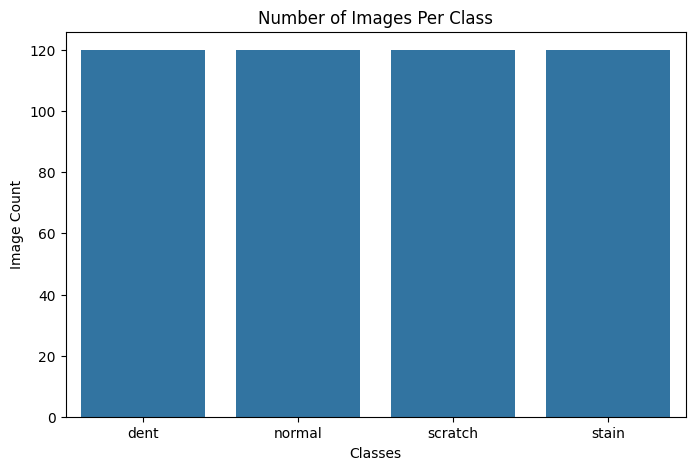

In [4]:
# ==========================================
# Visualize Class Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Number of Images Per Class")
plt.xlabel("Classes")
plt.ylabel("Image Count")

plt.show()

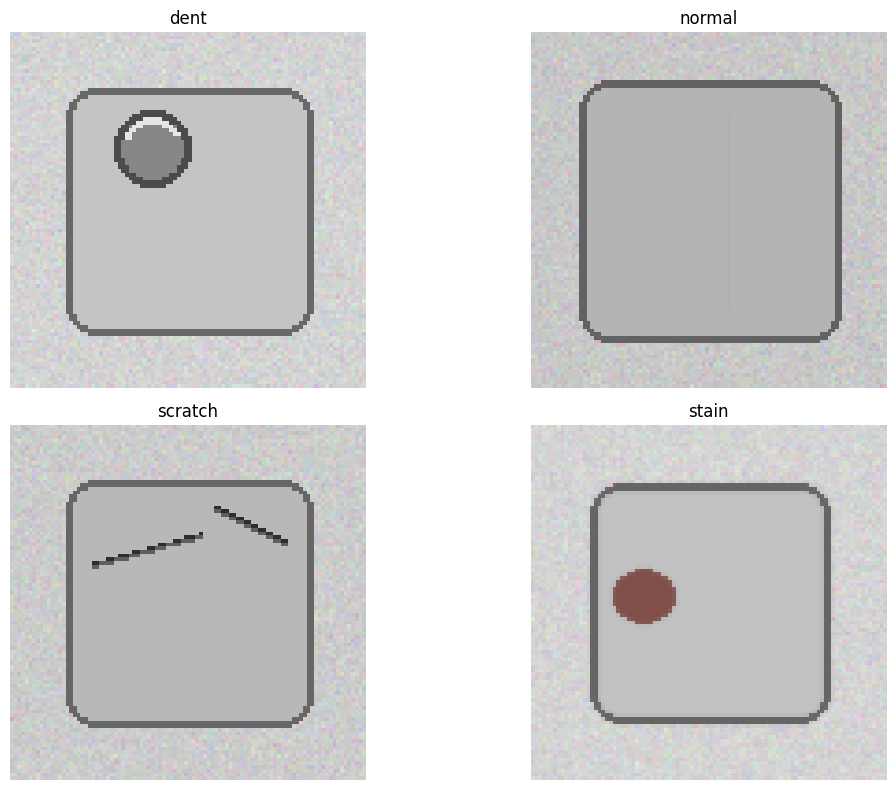

In [5]:
# ==========================================
# Display Sample Images From Each Class
# ==========================================

plt.figure(figsize=(12,8))

for i, class_name in enumerate(class_counts.keys()):
    
    class_folder = os.path.join(dataset_path, class_name)
    
    image_name = os.listdir(class_folder)[0]
    
    image_path = os.path.join(class_folder, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(2, 2, i+1)
    
    plt.imshow(image)
    
    plt.title(class_name)
    
    plt.axis("off")

plt.tight_layout()

plt.show()

In [6]:
# ==========================================
# Image Dimensions Analysis
# ==========================================

image_sizes = []

for class_name in class_counts.keys():
    
    class_folder = os.path.join(dataset_path, class_name)
    
    image_name = os.listdir(class_folder)[0]
    
    image_path = os.path.join(class_folder, image_name)
    
    image = Image.open(image_path)
    
    image_sizes.append(image.size)

print("Sample Image Dimensions:\n")

for class_name, size in zip(class_counts.keys(), image_sizes):
    print(f"{class_name}: {size}")

Sample Image Dimensions:

dent: (96, 96)
normal: (96, 96)
scratch: (96, 96)
stain: (96, 96)


# Task 3: Image Preprocessing

In this section, image data is prepared for CNN training.

The preprocessing steps include:
- Image resizing
- Pixel normalization
- Label encoding
- Train-test split

In [7]:
# ==========================================
# Load Images and Create Labels
# ==========================================

X = []
y = []

# Define image size
IMG_SIZE = 96

for class_name in class_counts.keys():
    
    class_folder = os.path.join(dataset_path, class_name)
    
    for image_name in os.listdir(class_folder):
        
        image_path = os.path.join(class_folder, image_name)
        
        # Open image
        image = Image.open(image_path)
        
        # Resize image
        image = image.resize((IMG_SIZE, IMG_SIZE))
        
        # Convert image to numpy array
        image_array = np.array(image)
        
        # Normalize pixel values
        image_array = image_array / 255.0
        
        # Store image
        X.append(image_array)
        
        # Store label
        y.append(class_name)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("Image Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

Image Dataset Shape: (480, 96, 96, 3)
Labels Shape: (480,)


In [8]:
# ==========================================
# Encode Labels
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded Labels:\n")
print(y_encoded[:10])

print("\nClass Mapping:\n")

for index, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {index}")

Encoded Labels:

[0 0 0 0 0 0 0 0 0 0]

Class Mapping:

dent --> 0
normal --> 1
scratch --> 2
stain --> 3


In [9]:
# ==========================================
# Split Dataset into Training and Testing
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Data Shape: (384, 96, 96, 3)
Testing Data Shape: (96, 96, 96, 3)

Training Labels Shape: (384,)
Testing Labels Shape: (96,)


# Task 4: CNN Model Building

In this section, a Convolutional Neural Network (CNN) model is created for image classification.

The CNN architecture includes:
- Convolution layers for feature extraction
- MaxPooling layers for dimensionality reduction
- Flatten layer for converting feature maps into vectors
- Dense layers for classification
- Dropout layer to reduce overfitting

The model is compiled using:
- Adam optimizer
- Sparse categorical crossentropy loss
- Accuracy as evaluation metric

In [10]:
# ==========================================
# Build CNN Model
# ==========================================

model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(96, 96, 3)
    )
)

# First Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
model.summary()

c:\Users\devan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training

In this section, the CNN model is trained using the training dataset.

The training process includes:
- Feeding training images into the CNN
- Learning image patterns through multiple epochs
- Validating model performance during training

The model learns to classify images into:
- dent
- normal
- scratch
- stain

In [11]:
# ==========================================
# Train CNN Model
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.2729 - loss: 3.0570 - val_accuracy: 0.3646 - val_loss: 1.3807
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.2895 - loss: 1.3819 - val_accuracy: 0.2500 - val_loss: 1.3617
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.3216 - loss: 1.3493 - val_accuracy: 0.5417 - val_loss: 1.2638
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5040 - loss: 1.2208 - val_accuracy: 0.5104 - val_loss: 1.0833
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.5131 - loss: 1.0707 - val_accuracy: 0.5938 - val_loss: 0.8934
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.6444 - loss: 0.8505 - val_accuracy: 0.7708 - val_loss: 0.6845
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.6793 - loss: 0.7813 - val_accuracy: 0.7500 - val_loss: 0.6946
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.7848 - loss: 0.6478 - val_accuracy: 0.885

# Task 6: Model Evaluation

In this section, the trained CNN model is evaluated using the testing dataset.

The evaluation includes:
- Test accuracy
- Test loss
- Model predictions
- Classification report
- Confusion matrix

This helps measure how well the CNN performs on unseen images.

In [12]:
# ==========================================
# Evaluate CNN Model
# ==========================================

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8021 - loss: 0.4750
Test Loss: 0.43982982635498047
Test Accuracy: 0.8229166865348816


# Task 7: Predictions and Performance Analysis

In this section, predictions are generated using the trained CNN model.

The performance analysis includes:
- Predicted labels
- Classification report
- Confusion matrix
- Visualization of model performance

This helps in understanding the strengths and weaknesses of the CNN classifier.

In [13]:
# ==========================================
# Generate Predictions
# ==========================================

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions Generated Successfully")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predictions Generated Successfully


In [14]:
# ==========================================
# Classification Report
# ==========================================

class_names = list(class_counts.keys())

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

Classification Report:

              precision    recall  f1-score   support

        dent       0.79      0.92      0.85        24
      normal       0.88      0.96      0.92        24
     scratch       0.91      0.42      0.57        24
       stain       0.77      1.00      0.87        24

    accuracy                           0.82        96
   macro avg       0.84      0.82      0.80        96
weighted avg       0.84      0.82      0.80        96



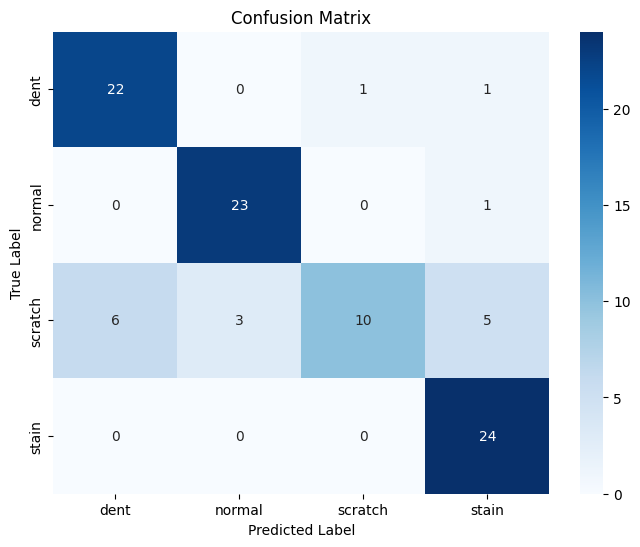

In [15]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Save figure
plt.savefig("Results/confusion_matrix.png")

plt.show()

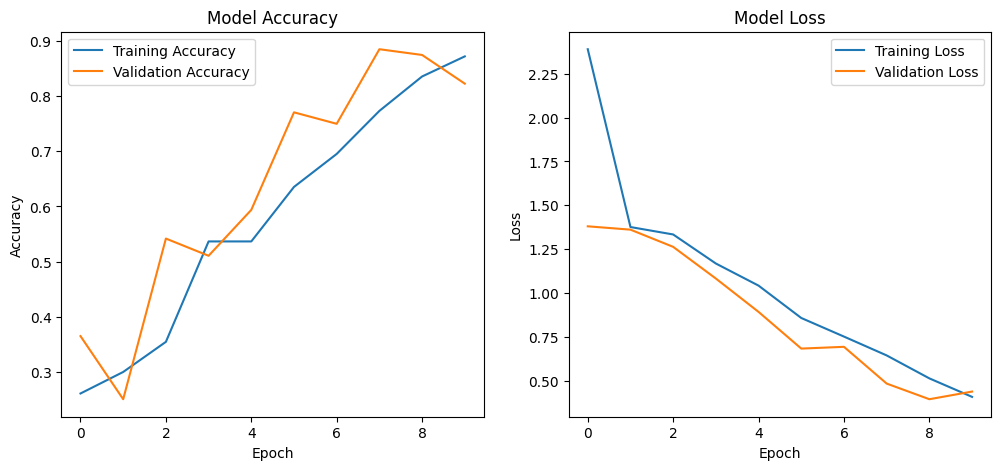

In [16]:
# ==========================================
# Training Accuracy and Loss Graphs
# ==========================================

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

# Save graph
plt.savefig("Results/training_performance.png")

plt.show()

In [17]:
# ==========================================
# Save Trained CNN Model
# ==========================================

model.save("Results/cnn_surface_defect_model.h5")

print("CNN Model Saved Successfully")

CNN Model Saved Successfully


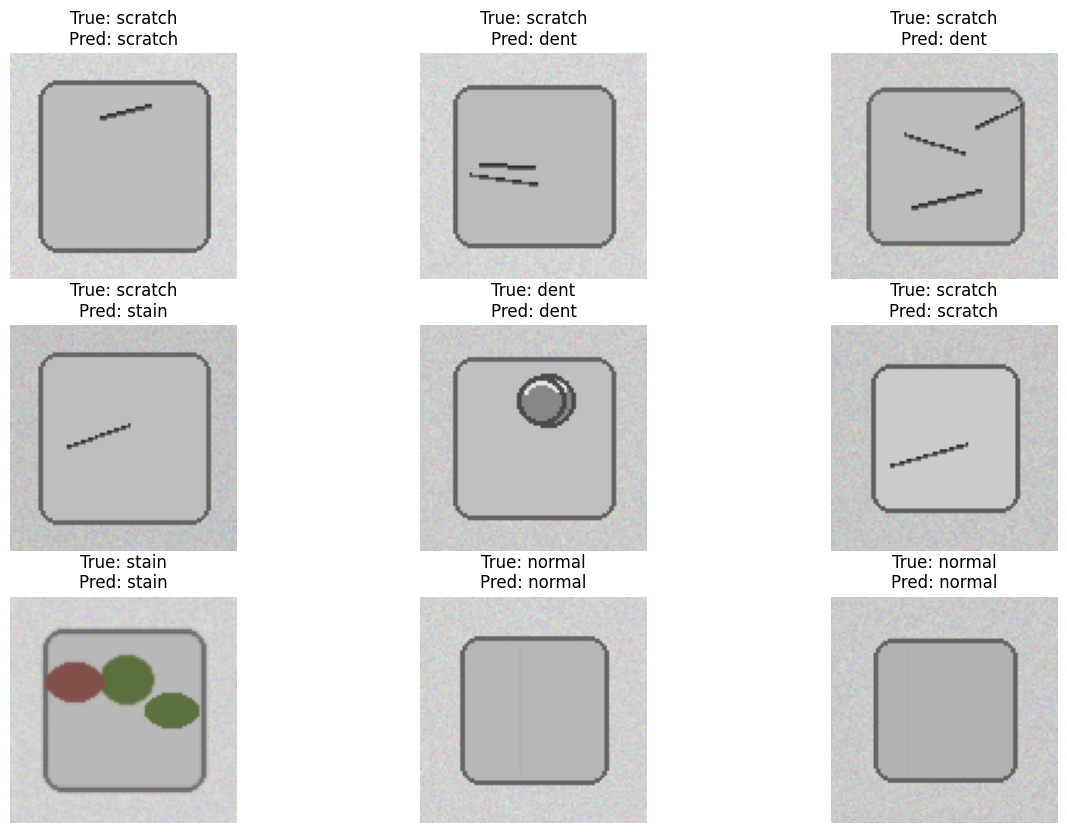

In [18]:
# ==========================================
# Display Sample Predictions
# ==========================================

plt.figure(figsize=(15, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_test[i])

    true_label = class_names[y_test[i]]
    predicted_label = class_names[y_pred[i]]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")

    plt.axis('off')

# Save figure
plt.savefig("sample_predictions/sample_predictions.png")

plt.show()